# ch-03-02의 시작!
# 선형회귀

# 농어무게를 예측하는 KNN 회귀모델을 보고하니까 클라이언트가 갑자기 길이가 50cm인 농어를 가져왔다!
# 역시 클라이언트는 개념이.없
# 그리고 농어의 길이를 50cm로 설정하고 회귀 모델로 예측을 하니 결과가 너무 차이가 났다,,,,,ㅈ
# 이를 통해 우리는 KNN의 한계를 알 수 있다.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

In [4]:
# 데이터 수집
perch_length = np.array([8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0])
perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0])


In [18]:
# 데이터 정리
# 훈련세트, 테스트 세트로 나누기
train_input, test_input, train_target, test_target = train_test_split(perch_length, perch_weight, random_state= 42)

In [20]:
# 데이터 정리
# 훈련세트와 테스트 세트 2차원으로 바꾸기
train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

In [21]:
# k가 3개인 모델 훈련
knr = KNeighborsRegressor(n_neighbors=3)

# KNN 회귀 훈련
knr.fit(train_input, train_target)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [22]:
# 50cm 대물 무게 예측,,두구
print(knr.predict([[50]]))

[1033.33333333]


In [23]:
# 위의 예측결과는 1kg가 조금 넘는다고 하는데 실제로는 훨씬 많이 나간다고 한다,,,,
# 문제 파악을 위해 훈련 세트와 50cm 농어, 그리고 이 농어의 친구들을 산점도로 표현하자.
# kneighbors 메서드를 사용하면 가장 가까운 이웃과의 거리와 이웃 샘플의 인덱스를 얻을 수 있다.

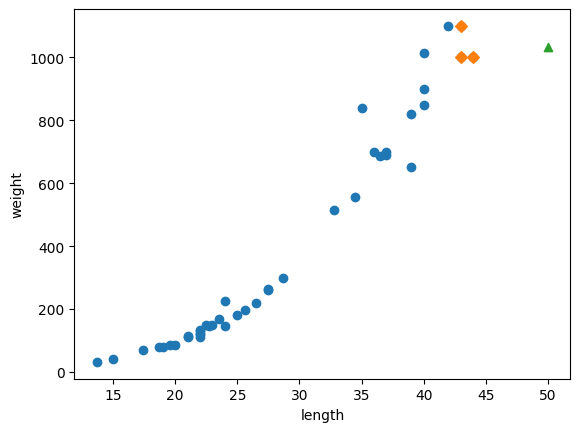

In [29]:
# 50cm 농어의 이웃 구하기
distances, indexes = knr.kneighbors([[50]])

# 훈련세트의 산점도 그리기
plt.scatter(train_input, train_target)

# 훈련세트중에서 이웃만 다시 그리기
plt.scatter(train_input[indexes], train_target[indexes], marker = 'D')

# 50cm 괴물 데이터
plt.scatter(50, 1033, marker = '^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()



In [31]:
# 이 산점도를 분석하자면, 길이가 늘어날 수록 무게가 증가하는 상식적인 현상을 보이고 있다.
# 그런데 클라이언트가 가져온 괴물은 길이가 50cm로 가장 큰데, 무게는 40cm인 친구와 같은 무게를 가지다니
# 이는 물고기 치고 이상한 현상이라 볼 수 있겠다.
# 하지만 이는 KNN 최근접이웃 알고리즘의 특성상 주위의 가장 가까운 3개(우리가 3개로 설정)의 무게의 평균이니
# 우리 KNN은 잘못이 없다. 

In [ ]:
# 이웃들의 평균 몸무게를 구해보면
print(np.mean(train_target[indexes]))

1033.3333333333333


In [33]:
# 위를 보면 알 수 있듯이 우리 KNN은 아무 잘못이 없었다.
# 이를 통해 우리는 새로운 샘플이 훈련세트의 범위를 벗어나면 엉뚱한 값을 예측한다는 점을 알 수 있게 되었다.
# print(knr.predict[[100]])을 해도 1033이 나올 것이다.

책의 저자는 이러한 상황이 마음에 들지 않나 봅니다. 그래서 한계가 있는 KNN을 버리고 다른 알고리즘을 찾아 떠납니다.

그 알고리즘이 선형회귀입니다.

선형회귀
널리 사용되는 대표적인 회귀 알고리즘
비교적 간단 성능 굿굿~
선형회귀는 특성이 하나인 경우 어떤 직선을 학습하는 알고리즘
특성을 가장 잘 나타내는 직선을 정하는 것이 핵심: w, b

우리는 scikitlearn의 linear_model 패키지 아래에 LinearRegression 클래스로 선형회귀 알고리즘을 사용 할 수 있다.


In [35]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

# 선형 회귀 모델을 훈련합니다.
lr.fit(train_input, train_target)

# 50cm 농어 예측
print(lr.predict([[50]]))

[1241.83860323]


In [36]:
# 위의 결과를 보면 1033을 예측했던 KNN 회귀보다 높은 결과를 예측한 우리의 LinearRegression이 있습니다.
# 이 결과를 도출한 과정을 살펴보겠슴당.

과정
하나의 직선은 기울기와 절편이 있어야 합니다.
x를 농어의 길이, y를 농어의 무게로 바꾸면 우리가 아는 일차함수의 모습을 띄게 됩니다.
그리고 우리는 lr 객체의 coef_와 intercept_ 속성을 print하여 자세한 과정을 볼 수 있습니다.

In [37]:
print(lr.coef_, lr.intercept_)

[39.01714496] -709.0186449535474


In [ ]:
# 여기서 기울기를 계수를 뜻하는 coefficient라고 합니당.
# 그리고 coef_와 intercept_를 알고리즘이 찾은 값이라는 뜻으로 Parameter라고 합니다.

In [39]:
#  이제는 LinearRegression의 산점도를 그려보겠습니다.

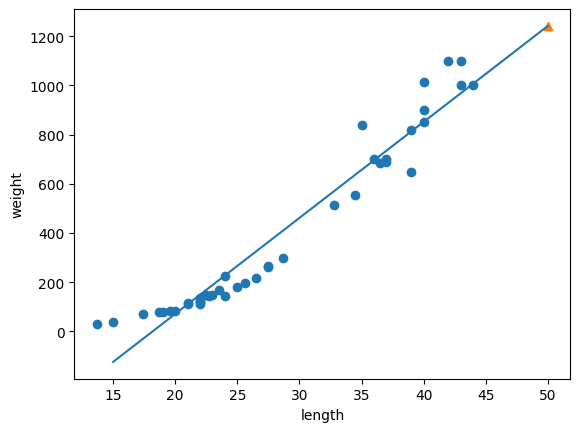

In [40]:
# 산점도
plt.scatter(train_input, train_target)\
# 15에서 50까지 1차 방정식
plt.plot([15,50], [15*lr.coef_ + lr.intercept_, 50*lr.coef_ + lr.intercept_])

plt.scatter(50, 1241.8, marker = '^')
plt.xlabel("length")
plt.ylabel("weight")
plt.show()

바로 이거시 LinearRegrssion이 찾은 최적의 직선입니다.
성공입니다~~

In [41]:
# 이제 훈련세트와 테스트세트에 대한 R**2결정계수를 확인하면
print(lr.score(train_input, train_target))
print(lr.score(test_input, test_target))

0.9398463339976041
0.824750312331356


결과를 보면 과대적합,,이라기에는 잘 모르겠다가 책의 입장입니다.
저도 잘 모르겠습니다. 알 수 있는 건 처음 KNN보다 정확률은 높지 않군요.
이는, 강사님이 말씀하신 것처럼 값들이 0아래에 있을 떄 값들을 계산하는 것이 불가능하기에 그렇다고 봅니다.

다항회귀

이는 선형회귀를 통해 계산한 값 중에서 무게가 0이하로 내려가는 친구들이 있는데 이는 현실세계에서는 불가능한 일이기 때문입니다.

사실 농어의 길이와 무게에 대한 값은 이차방정식에 가까워 보입니다. 그래서 우리가 이차방정식을 봤군요,,,,,

2차 방정식의 그래프를 그리려면, 길이를 제곱한 항이 훈련세트에 추가되어야 합니다. 그리고 numpy를 통해 간단히 만들 수 있습니다.

농어의 길이를 제곱하여 원래 데이터 앞에 붙여 보겠습니다.

이는 column_stack을 사용하면 아주 간단하다고 합니당,, 방식은 train_input을 제곱한 것과 train_input 두 배열을 나란히 붙이면 됩니다.test_input도 마찬가지입니다.

In [43]:
train_poly = np.column_stack((train_input ** 2, train_input))
test_poly = np.column_stack((test_input ** 2, test_input))

In [44]:
print(train_poly.shape, test_poly.shape)

(42, 2) (14, 2)


원래 특성인 길이를 제곱하여 2열이 생겼습니다. 이제 이차방정식을 할 수 있습니다! train_input **2에도 
numpy 브로드캐스팅이 적용된다는 데 잘 이해가 가지는 않습니다. 더 공부를,,,
쨌든 이제, train_poly를 활용하여 선형 회귀 모델을 다시 훈련하겟습니다.
이때, 2차 방정식 그래프를 찾기 위해 훈련세트에 제곱항을 추가했지만, 타깃값은 그대로 사용해야 합니다!!!!!!

In [48]:
# 훈련
lr = LinearRegression()
lr.fit(train_poly, train_target)

print(lr.predict([[50**2, 50]]))

[1573.98423528]


In [49]:
#  결과값은 더 높은 1573이 나왔습니다!!!
#  한 번 절편과 기울기를 출력하겠습니다.
print(lr.coef_, lr.intercept_)

[  1.01433211 -21.55792498] 116.0502107827827


In [ ]:
# (15-49까지) 구간별 직선 그리기.
point = np.arange(15,50)

# 훈련 세트 산점도
plt.scatter(train_input, train_target)

# 2차 방정식(15에서 49까지)
plt.plot(point, 1.01*point**2-21.6*point+116.05)

# 15에서 